In [15]:
import os, sys, pathlib, importlib
import pandas as pd
import json
import time
from tqdm import tqdm
sys.path.append(os.path.abspath(".."))
from utils import download_pic
from utils.download_pic import download_images_batch

## check

43056 23789
18682


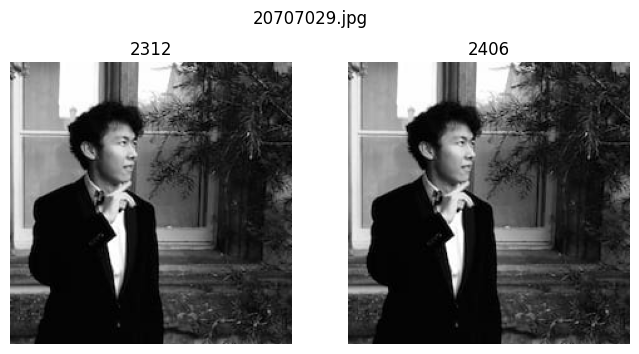

In [ ]:
## check duplicates:
import matplotlib.pyplot as plt

folder1='images\paris_2406'
folder2='images\paris_2312'
paris2312=os.listdir(folder1)
paris2406=os.listdir(folder2)

print(len(paris2312), len(paris2406))
comm=list(set(paris2312).intersection(set(paris2406)))
print(len(comm))


## vis
import matplotlib.pyplot as plt
import os


f=comm[10]
img1 = plt.imread(os.path.join(folder1, f))
img2 = plt.imread(os.path.join(folder2, f))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title('2312')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title('2406')
plt.axis('off')

plt.suptitle(f)
plt.show()


## input 22032026


In [14]:
DATA_FOLDER="../data_processed"
IMAGES_FOLDER='images'

os.makedirs(IMAGES_FOLDER, exist_ok=True)

input_output={}
for folder in [ f for f in os.listdir(DATA_FOLDER) if not f.endswith('.csv')]:
    # folder = city+time

    # ---listings---
    files=os.listdir(os.path.join(DATA_FOLDER, folder))
    for f in files:
        if f.startswith('listings_processed'):
            path_listings=os.path.join(DATA_FOLDER, folder, f)
            path_listings_zsc=os.path.join(DATA_FOLDER, folder, f"listings_zsc_{folder}.csv")
    path_results_zsc=os.path.join(DATA_FOLDER, folder, f"resultsZSC_{folder}.csv")

    # ---images folder---
    pic_folder=os.path.join(IMAGES_FOLDER, folder)
    os.makedirs(pic_folder, exist_ok=True)

    # --resultsface---
    resultsFACE_folder=os.path.join(IMAGES_FOLDER, 'results')
    os.makedirs(resultsFACE_folder, exist_ok=True)

    path_results_face=os.path.join(resultsFACE_folder, f"face_{folder}.json")
    path_results_deepface=os.path.join(resultsFACE_folder, f"deepface_{folder}.json")

    # ---gather---
    input_output[folder]={"listings":path_listings,
              "results_zsc":path_results_zsc,
              "listings_zsc":path_listings_zsc,

              'pic_folder':pic_folder,
              'results_face':path_results_face,
              "results_deepface":path_results_deepface}

for k,v in input_output.items():
    print(f"{k}".center(100,'-'))
    path_listings=v['listings']
    path_results_zsc=v['results_zsc']
    path_listings_zsc=v['listings_zsc']

    pic_folder=v['pic_folder']
    path_results_face=v['results_face']
    path_results_deepface=v['results_deepface']
    print('DATA:')
    print(path_listings)
    print(path_results_zsc)
    print(path_listings_zsc,"\n")
    print("PIC FOLDER: ",pic_folder)
    print(path_results_face)
    print(path_results_deepface,"\n")

--------------------------------------------london_2306---------------------------------------------
DATA:
../data_processed\london_2306\listings_processed_london_2306_42356.csv
../data_processed\london_2306\resultsZSC_london_2306.csv
../data_processed\london_2306\listings_zsc_london_2306.csv 

PIC FOLDER:  images\london_2306
images\results\face_london_2306.json
images\results\deepface_london_2306.json 

--------------------------------------------london_2406---------------------------------------------
DATA:
../data_processed\london_2406\listings_processed_london_2406_49856.csv
../data_processed\london_2406\resultsZSC_london_2406.csv
../data_processed\london_2406\listings_zsc_london_2406.csv 

PIC FOLDER:  images\london_2406
images\results\face_london_2406.json
images\results\deepface_london_2406.json 

---------------------------------------------paris_2306---------------------------------------------
DATA:
../data_processed\paris_2306\listings_processed_paris_2306_32901.csv
../data_

## download pics

In [20]:
importlib.reload(download_pic)
from utils.download_pic import download_images_batch

path_df=input_output['paris_2406']['listings']
pic_folder=input_output['paris_2406']['pic_folder']
df=download_images_batch(path_df=path_df, pic_folder=pic_folder, max_workers=10)

[check]host_pic_is_valid
True     43071
False      186
Name: count, dtype: int64
[info] filtered by 'host_pic_is_valid'!
[check] has pic+ dropna + drop_duplicates: 62738 => 0!
[info] ALL pics downloaded:)



In [ ]:
importlib.reload(download_pic)
from utils.download_pic import download_images_batch

for i, paths in input_output.items():
    print(f"{i}".center(100,'-'))    
    path_df=paths['listings']
    pic_folder=paths['pic_folder']
    print(f"path df:{path_df}")
    print(f"pic_folder: {pic_folder}")
    df=download_images_batch(path_df=path_df, pic_folder=pic_folder, max_workers=10)
    break

--------------------------------------------london_2306---------------------------------------------
path df:../data_processed\london_2306\listings_processed_london_2306_42356.csv
pic_folder: images\london_2306
[check] has pic+ dropna + drop_duplicates: 42356 => 22251!
[info] 0/22251 downloaded; 22251 /22251 to download!

[info] no / no valid host pic: 1370/22251.




[warning] invalid URL: https://a0.muscache.com/im/pictures/user/8028dbae-04f9-4d9a-812a-9f47af3cb219.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/users/180838/profile_pic/1314871443/original.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/User-565948/original/27a304ca-cdfe-4016-a016-bade87efee0e.jpeg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/c3732e06-6ade-4697-a5a8-5982d3072c16.jpg?aki_policy=profile_x_medium


...


[warning] invalid URL: https://a0.muscache.com/im/pictures/user/c013e583-b2ea-4c6a-902a-6ac4f2c104cb.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/c1deb1f9-f0be-4cef-ae2e-c45767fb3b0e.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/5f998b48-e18f-4f35-b3a7-80b43d80f0d8.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/pictures/user/1a541a5d-c7d5-4e55-9bce-3df632a19327.jpg?aki_policy=profile_x_medium



[warning] invalid URL: https://a0.muscache.com/im/users/9718714/profile_pic/1383144896/original.jpg?aki_policy=profile_x_medium
